# Quality analysis in linear regression

As a reminder, the quality measure R^2 score returns a value between 0 and 1, where 1 means a perfect prediction and 0 means a very simple regression model. The R^2 equation is:

$$R^2 = 1 - \frac{\sum_{i=0}^{n-1}(y_i-f(x_i))^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2}$$

where $f(x_i)$ is the regressor's prediction for the sample $x_i$

This code uses Lasso regression, a type of linear regression with regularization, to analyze the diabetes dataset included in scikit-learn. First, it loads the dataset, selects a specific feature such as blood pressure or the variable s3, and splits the data into training and testing sets. Then, it trains several Lasso models using different alpha values (0.01, 0.3, and 1). The alpha parameter controls the strength of the penalty applied to the model: smaller values allow the model to fit the data more closely, while larger values simplify the regression and reduce complexity. For each model, the R2 score is calculated to measure how well the predictions explain the real data, where 1 means a perfect fit and 0 indicates a very poor model.

The program also creates graphs that compare the predicted values with the real values for both the training and testing datasets. This makes it possible to visualize how the model behaves with different alpha values and identify issues such as overfitting, when the model performs very well on training data but poorly on testing data, or underfitting, when performance is poor in both cases. This type of code is commonly used in machine learning and predictive analysis to study relationships between numerical variables, reduce the effect of less important features, and improve the model's ability to generalize to new data.


In [1]:
# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn import linear_model

In [2]:
# =========================
# Esta función entrena y visualiza modelos de regresión Lasso para tres valores distintos de alpha,
# comparando gráficamente su ajuste y precisión tanto en el conjunto de entrenamiento como en el
# de prueba mediante una matriz de subgráficos.
# =========================

def model(X_train, y_train, X_test, y_test):
  fig, axs = plt.subplots(2, 3, figsize=(16, 7))
  training = 0; testing = 1;
  for set_type, label in zip((training,testing),('Training_Set','Testing_Set')):
    for alpha, column in zip([0.01,0.3,1],[0,1,2]):
      lasso = linear_model.Lasso(alpha=alpha)
      lasso.fit(X_train, y_train)

      if set_type == training:
        #training accuracy
        training_score = lasso.score(X_train, y_train)
        y_pred = lasso.predict(X_train)
        plot(axs, X_train, y_train, y_pred, alpha, set_type, column, label+', score: {:3.2f}'.format(training_score))
      else:
        #testing accuracy
        testing_score = lasso.score(X_test, y_test)
        y_pred = lasso.predict(X_test)
        plot(axs, X_test, y_test, y_pred, alpha, set_type, column, label+', score: {:3.2f}'.format(testing_score))
  plt.show()
  return

In [3]:
# =========================
# Esta función grafica en una sub-ventana específica la comparación entre los valores
# reales y las predicciones de un modelo Lasso, incluyendo el valor de alpha y etiquetas descriptivas.
# =========================

def plot(axs, data2D, target1D, predict1D, alpha, set_type, column, label):
  axs[set_type,column].plot(data2D, target1D, 'y.', markersize = 6)
  axs[set_type,column].plot(data2D, predict1D, 'k-')
  axs[set_type,column].set_title('Lasso, alpha:' + str(alpha) + ', ' + label)
  axs[set_type,column].grid()
  return

In [4]:
# =========================
# CARGA DEL DATASET
# =========================
# Diabetes dataset:
# Dataset personas con diabetes.

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

blood_preasure = 3; s3 = 6;

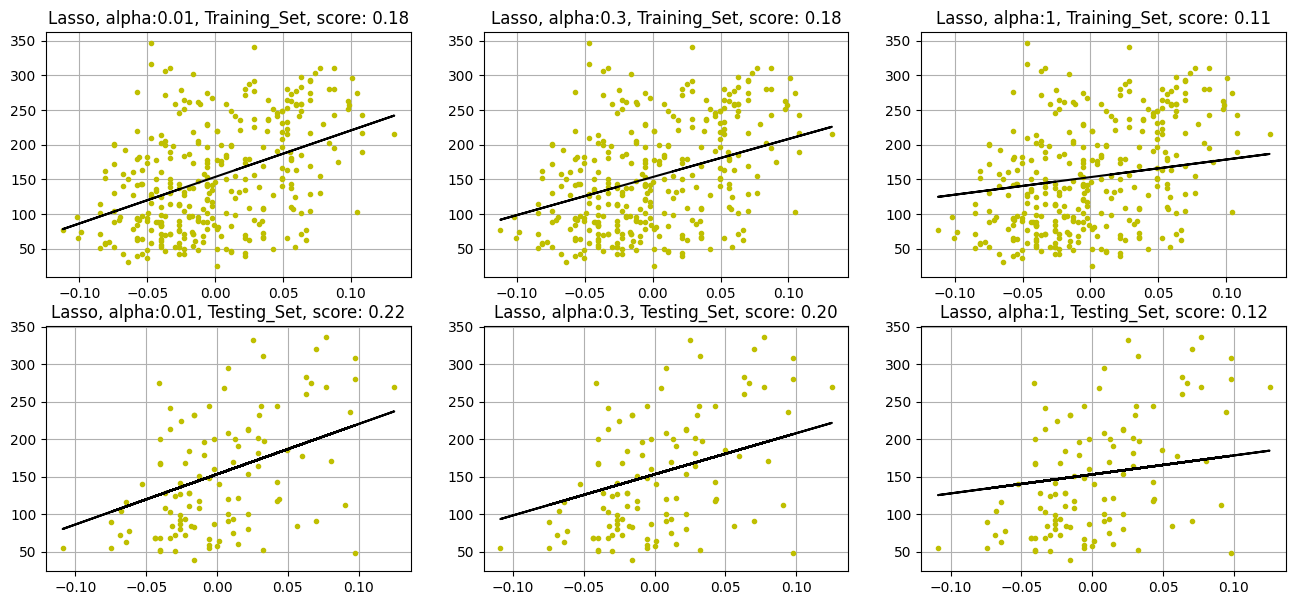

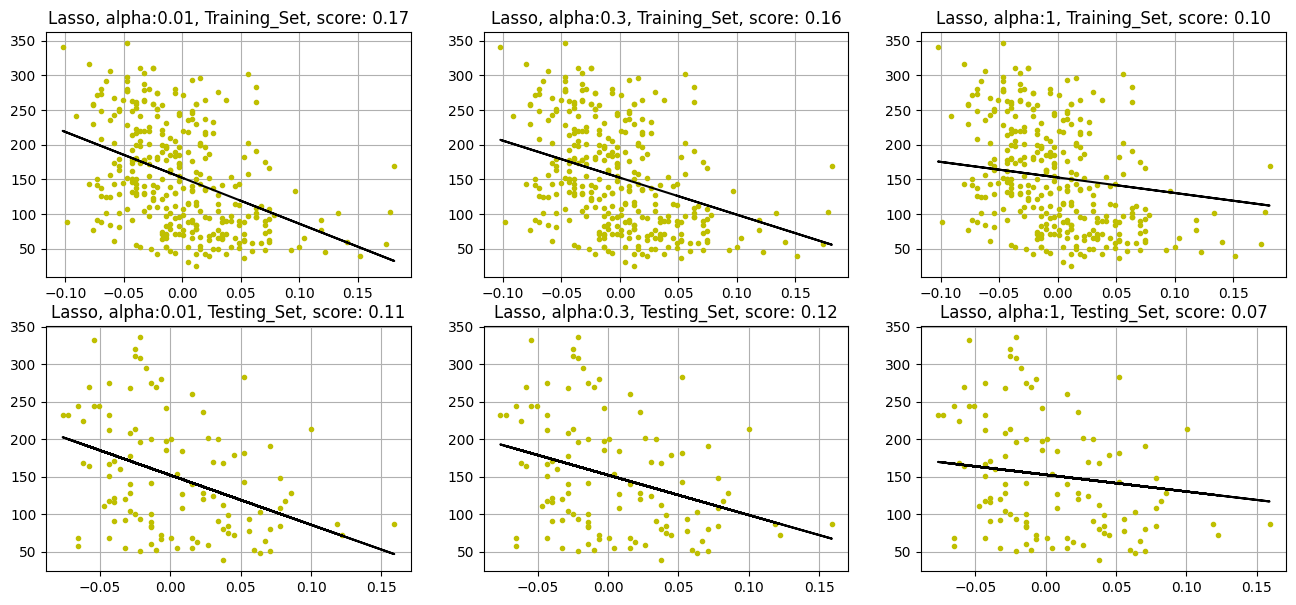

In [5]:
# =========================
# El código itera sobre dos variables específicas para entrenar y evaluar un modelo
# de regresión con cada una por separado, asegurando que los datos tengan el formato
# de matriz necesario.
# =========================

for feature in (blood_preasure, s3):
  X_train, X_test, y_train, y_test = train_test_split(X[:,feature], y, random_state= 60)
  # regression fit method need a data matrix as argument so we define it
  X_train = X_train[:, np.newaxis]
  #the score method need a data matrix as argument also
  X_test = X_test[:, np.newaxis]

  model(X_train, y_train, X_test, y_test)
  print()

